# Data Exploration and Cleaning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer

# Custom modules
import sys
sys.path.append('../')
from utils.preprocessing import preprocess_text
from utils.visualization import plot_rating_distribution, plot_text_length_distribution, generate_wordcloud, plot_top_ngrams

# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

In [2]:
# Load data
df = pd.read_csv('../data/raw/insurance_reviews.csv')
print(f"Dataset shape: {df.shape}")
print("\nFirst 5 rows:")
display(df.head())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nBasic statistics:")
print(df.describe())

Dataset shape: (1000, 3)

First 5 rows:


,review,rating,category
0,"Great insurance, fast claims processing.",4,Coverage
1,"Poor customer service, took forever to get a r...",5,Coverage
2,"Affordable premiums, but coverage is limited.",3,Coverage
3,"Excellent support, highly recommend.",5,Coverage
4,"Claims denied without reason, very frustrating.",5,Coverage



Data types:
review      object
rating       int64
category    object
dtype: object

Missing values:
review      0
rating      0
category    0
dtype: int64

Basic statistics:
            rating
count  1000.000000
mean      3.004000
std       1.433192
min       1.000000
25%       2.000000
50%       3.000000
75%       4.000000
max       5.000000


In [3]:
# Text Preprocessing
print("Original review:")
print(df['review'].iloc[0])
print("\nPreprocessed review:")
df['cleaned_review'] = df['review'].apply(preprocess_text)
print(df['cleaned_review'].iloc[0])

# Save processed data
df.to_csv('../data/processed/cleaned_reviews.csv', index=False)
print("\nProcessed data saved to ../data/processed/cleaned_reviews.csv")

Original review:
Great insurance, fast claims processing.

Preprocessed review:
great insurance fast claim processing

Processed data saved to ../data/processed/cleaned_reviews.csv


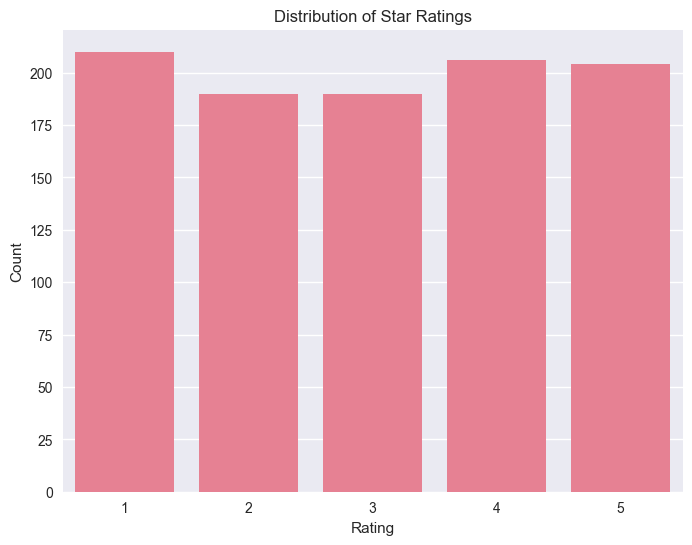

In [4]:
# Exploratory Data Analysis

# Rating distribution
plot_rating_distribution(df)

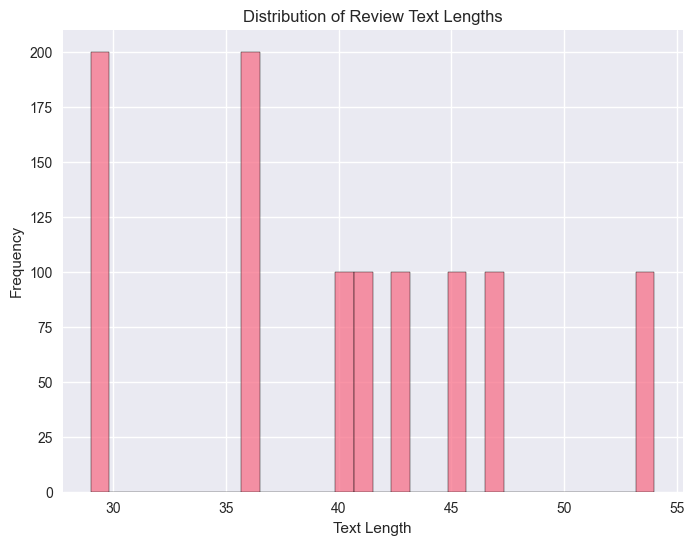

In [5]:
# Text length distribution
plot_text_length_distribution(df)

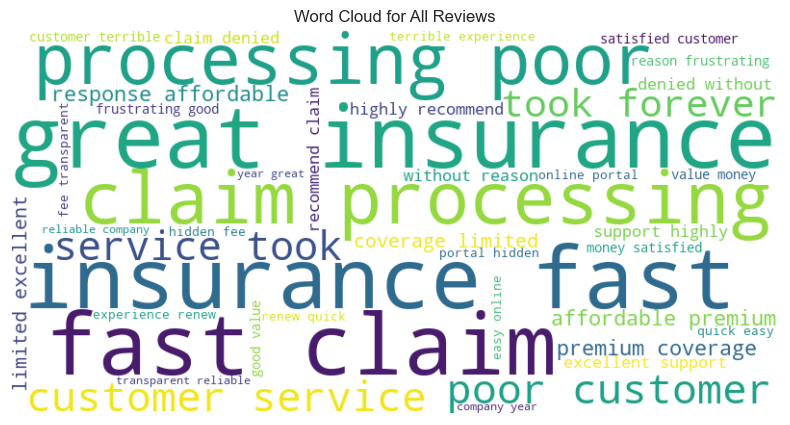

In [6]:
# Word cloud
generate_wordcloud(df['cleaned_review'], 'Word Cloud for All Reviews')

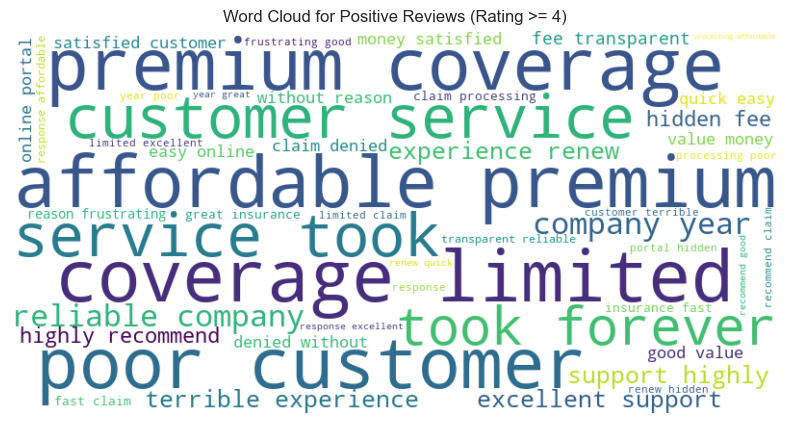

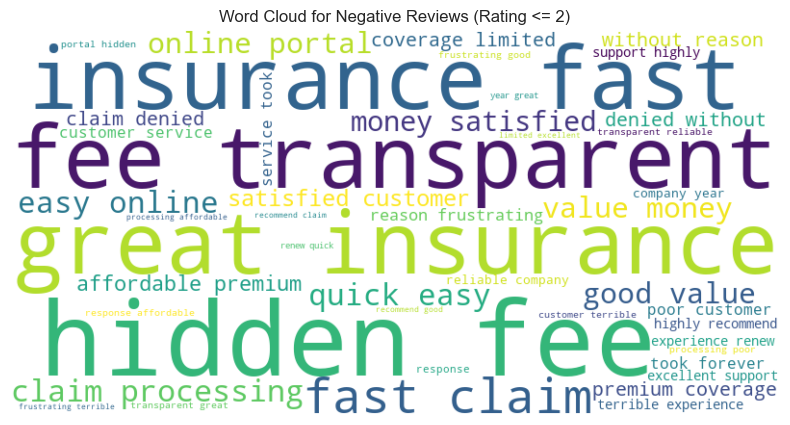

In [7]:
# Word clouds for positive and negative reviews
positive_reviews = df[df['rating'] >= 4]['cleaned_review']
negative_reviews = df[df['rating'] <= 2]['cleaned_review']

generate_wordcloud(positive_reviews, 'Word Cloud for Positive Reviews (Rating >= 4)')
generate_wordcloud(negative_reviews, 'Word Cloud for Negative Reviews (Rating <= 2)')

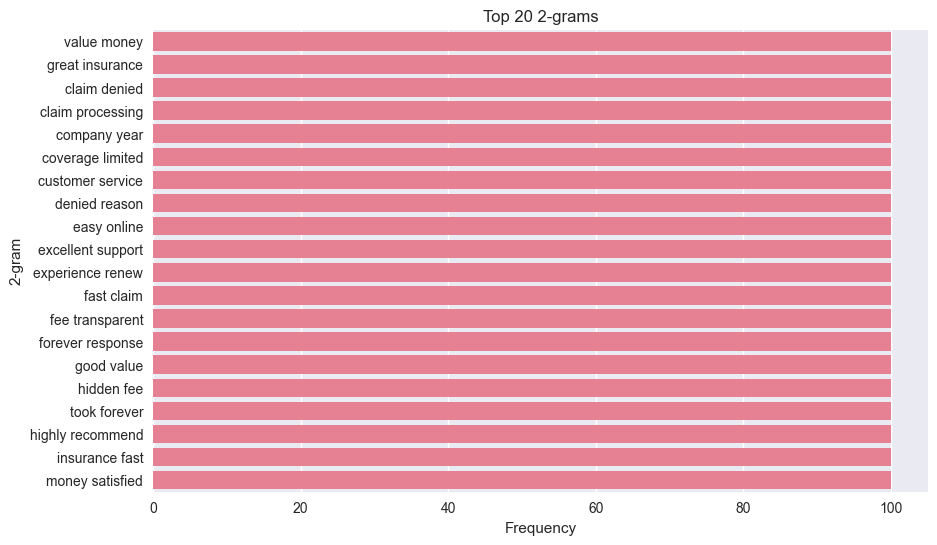

In [8]:
# Top bigrams
plot_top_ngrams(df['cleaned_review'], n=2, top_k=20)

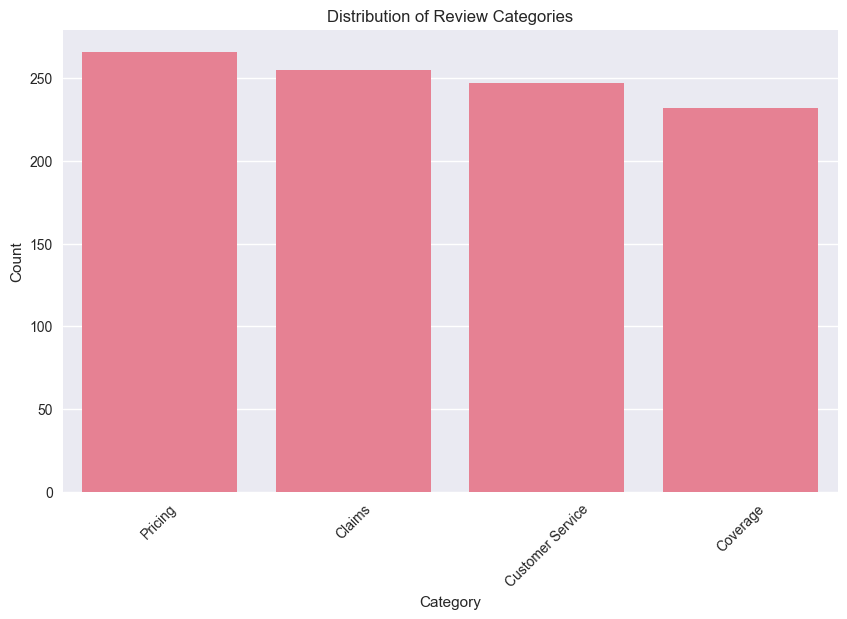

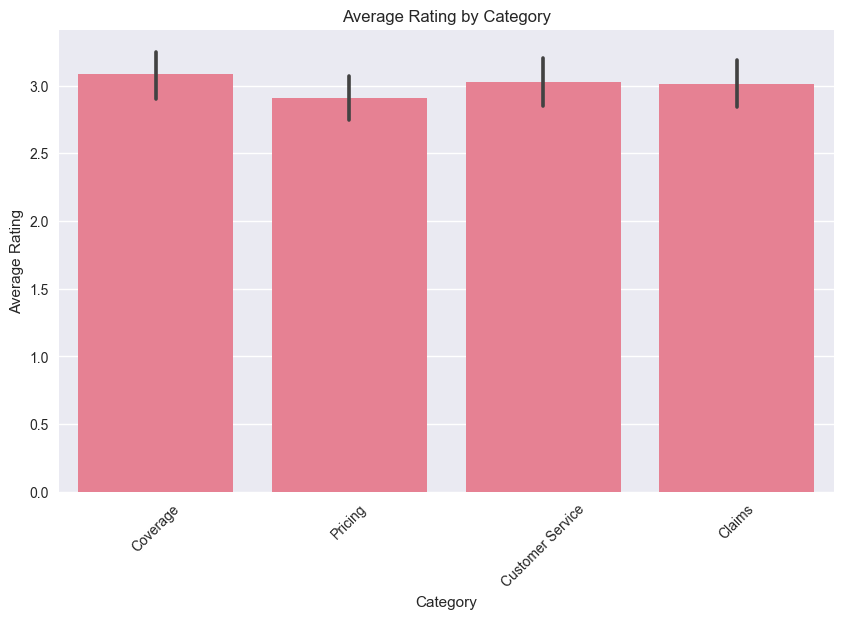

In [9]:
# Category analysis
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='category', order=df['category'].value_counts().index)
plt.title('Distribution of Review Categories')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# Average rating by category
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='category', y='rating', estimator=np.mean)
plt.title('Average Rating by Category')
plt.xlabel('Category')
plt.ylabel('Average Rating')
plt.xticks(rotation=45)
plt.show()